# Student Success — Semester-One Review Support

**Muhammad Pangeran Nabil · Portfolio edition v1.0.0**

Studi kasus prediksi retrospektif status mahasiswa dengan informasi sampai akhir semester 1.
Konteks bisnis: Jaya Jaya Institut (fiktif). Sumber: dataset UCI melalui Dicoding.

Notebook ini menjalankan training, seleksi, kalibrasi, evaluasi, dan pemuatan ulang artefak dari kode yang sama dengan aplikasi.
Original submission tersimpan pada tag `dicoding-submission-v1.0.0`.

**Navigasi:** 1. Business understanding · 2. Data & quality · 3. Protocol · 4. Modeling ·
5. Evaluation · 6. Interpretation · 7. Deployment · 8. Conclusions & actions.

## 1. Business understanding

Tujuan: membantu dosen wali menyusun prioritas peninjauan setelah semester 1. Prediksi tidak menjadi keputusan akademik otomatis.

| Keputusan desain | Pilihan |
|---|---|
| Unit analisis | Satu mahasiswa dalam dataset historis |
| Input utama | 14 fitur pendaftaran dan akademik semester 1 |
| Target | Dropout / Enrolled / Graduate pada akhir durasi normal program |
| Pengguna | Dosen wali / tim pendampingan dalam demonstrasi |
| Output | Distribusi probabilitas, kelas paling mungkin, kategori peninjauan |
| Seleksi model | Mean macro F1 pada 5-fold CV |
| Kebijakan peninjauan | Threshold yang memaksimalkan Dropout F2 pada policy validation |

**Batas temporal:** tanggal dropout tidak tersedia. “Akhir semester 1” menjelaskan himpunan fitur, bukan bukti bahwa setiap prediksi dibuat sebelum dropout. Enrolled bukan label aman. Keberhasilan intervensi belum diukur.

F2 dipakai sebagai asumsi desain demo yang memberi perhatian lebih besar pada recall. Precision dan beban peninjauan tetap dilaporkan; belum ada kapasitas tim yang disepakati institusi nyata.

In [1]:
import os
for key in ['OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS']:
    os.environ.setdefault(key, '1')
import sys
from pathlib import Path
ROOT = Path.cwd()
if not (ROOT / 'student_success').is_dir():
    raise RuntimeError('Jalankan notebook dari root repository.')
sys.path.insert(0, str(ROOT))
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from student_success.config import DATA_PATH, ARTIFACT_DIR, REPORT_DIR, PROTOCOL, CLASS_NAMES
from student_success.schema import FEATURES, FIELDS, schema_records, validate_features, defaults
from student_success.inference import load_bundle, predict_frame, sha256_file
from student_success.train import EXPECTED_DATA_SHA256
print('Python:', sys.version.split()[0])
print('Project:', ROOT.name)

Python: 3.12.14
Project: student-success-prediction


## 2. Data understanding dan pemeriksaan kualitas

Data asli dipertahankan pada `data/raw/students.csv`, delimiter titik koma, checksum dikunci.
Sumber awal menggabungkan data pendaftaran dengan hasil semester 1 dan 2; target mencatat outcome pada akhir durasi normal program.

Referensi primer: [UCI dataset 697](https://doi.org/10.24432/C5MC89).
Kolom kategori berkode angka tidak otomatis bermakna kontinu. Unknown pada pendidikan orang tua merupakan ketidaklengkapan semantik meskipun tidak berupa null.

In [2]:
data = pd.read_csv(DATA_PATH, sep=';')
assert sha256_file(DATA_PATH) == EXPECTED_DATA_SHA256
X_checked = validate_features(data)
print('Raw shape:', data.shape)
print('Selected features:', X_checked.shape)
print('Null eksplisit:', int(data.isna().sum().sum()))
print('Duplikat penuh:', int(data.duplicated().sum()))
data.head()

Raw shape: (4424, 37)
Selected features: (4424, 14)
Null eksplisit: 0
Duplikat penuh: 0


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
quality = pd.DataFrame({
    'dtype': data.dtypes.astype(str),
    'unique': data.nunique(),
    'nulls': data.isna().sum(),
})
quality

,dtype,unique,nulls
Marital_status,int64,6,0
Application_mode,int64,18,0
Application_order,int64,8,0
Course,int64,17,0
Daytime_evening_attendance,int64,2,0
Previous_qualification,int64,17,0
Previous_qualification_grade,float64,101,0
Nacionality,int64,21,0
Mothers_qualification,int64,29,0
Fathers_qualification,int64,34,0


In [4]:
counts = data.Status.value_counts().reindex(CLASS_NAMES)
pd.DataFrame({'count': counts, 'proportion': counts / len(data)})

,count,proportion
Status,,
Dropout,1421,0.321203
Enrolled,794,0.179476
Graduate,2209,0.499322


In [5]:
unknowns = {c: int(data[c].eq(34).sum()) for c in ['Mothers_qualification', 'Fathers_qualification']}
print('Kode Unknown (34):', unknowns)
print('Kolom tersebut tidak digunakan model utama; tetap dicatat pada kualitas sumber.')

Kode Unknown (34): {'Mothers_qualification': 130, 'Fathers_qualification': 112}
Kolom tersebut tidak digunakan model utama; tetap dicatat pada kualitas sumber.


### Kontrak fitur dan alasan eksklusi

Fitur kategori diberi mapping eksplisit. Nilai sumber memakai skala 0–200 untuk nilai masuk, 0–20 untuk nilai semester; curricular units tidak otomatis identik dengan SKS Indonesia.

Enam fitur semester 2 dikeluarkan. Debtor, Tuition_fees_up_to_date, Scholarship_holder, dan indikator makroekonomi dikeluarkan karena timing operasional tidak cukup jelas untuk kontrak prediksi ini. Gender, kebangsaan, marital status, kebutuhan khusus, pekerjaan/kualifikasi orang tua, displaced dan international tidak diperlukan dalam formulir utama. Eksklusi atribut langsung tidak menjamin tidak ada bias melalui fitur lain.

Batas usia 16–100 dan batas jumlah unit/evaluasi merupakan kontrak operasional demo, bukan klaim batas universal institusi. Nilai valid yang di luar rentang pengembangan diberi peringatan.

In [6]:
schema_table = pd.DataFrame(schema_records())
schema_table[['feature', 'label', 'kind', 'low', 'high', 'group']]

,feature,label,kind,low,high,group
0,Course,Program studi,category,0,10000,Pendaftaran
1,Application_mode,Jalur pendaftaran,category,0,60,Pendaftaran
2,Application_order,Urutan pilihan,integer,0,9,Pendaftaran
3,Daytime_evening_attendance,Jadwal kuliah,category,0,1,Pendaftaran
4,Previous_qualification,Pendidikan sebelumnya,category,0,50,Pendaftaran
5,Previous_qualification_grade,Nilai pendidikan sebelumnya,continuous,0,200,Pendaftaran
6,Admission_grade,Nilai penerimaan,continuous,0,200,Pendaftaran
7,Age_at_enrollment,Usia saat masuk,integer,16,100,Pendaftaran
8,Curricular_units_1st_sem_credited,Unit yang diakui / transfer,integer,0,60,Semester 1
9,Curricular_units_1st_sem_enrolled,Unit yang diambil,integer,0,60,Semester 1


In [7]:
excluded = [c for c in data if c not in FEATURES and c != 'Status']
print('Fitur terpilih:', len(FEATURES))
print('Fitur tidak dipakai:', len(excluded))
pd.DataFrame({'excluded_feature': excluded})

Fitur terpilih: 14
Fitur tidak dipakai: 22


,excluded_feature
0,Marital_status
1,Nacionality
2,Mothers_qualification
3,Fathers_qualification
4,Mothers_occupation
5,Fathers_occupation
6,Displaced
7,Educational_special_needs
8,Debtor
9,Tuition_fees_up_to_date


## 3. Desain evaluasi sebelum pemodelan

| Bagian | Jumlah | Fungsi |
|---|---:|---|
| Model development | 2.654 | Seleksi 5-fold CV, kemudian fit model terpilih |
| Policy validation | 885 | Memilih threshold peninjauan |
| Historical holdout | 885 | Pelaporan akhir setelah model dan threshold dikunci |

Holdout memakai pembagian historis 20% dari submission. Data tersebut telah dilihat sebelumnya, sehingga hasil tidak disebut evaluasi eksternal yang independen.

Preprocessing dan kalibrasi 3-fold berada **di dalam** setiap fold training. Pemilihan tiga kandidat menggunakan macro F1; Dummy merupakan baseline. Setelah pemilihan, model difit pada 60% data, threshold ditetapkan dari validation, kemudian holdout dibuka. Tidak dilakukan refit seluruh data setelah melihat holdout.

Logistic admission-only merupakan pembanding tetap untuk melihat manfaat fitur akademik awal, bukan kandidat tambahan yang dipilih setelah melihat holdout.

In [8]:
pd.DataFrame({'setting': list(PROTOCOL), 'value': [str(v) for v in PROTOCOL.values()]})

,setting,value
0,version,semester1-v1
1,scenario,Retrospective status prediction using information through semester 1
2,target,Status at the end of the normal course duration; not time-to-dropout
3,seed,42
4,split,60% model development / 20% policy validation / 20% historical holdout
5,holdout_caveat,"Same historical 20% split as the submission; already inspected in the old project, not pristine external validation."
6,selection,Highest mean 5-fold macro F1; candidate order breaks exact ties.
7,calibration,"3-fold sigmoid calibration within each training fold, ensemble=True"
8,policy,"One review threshold maximizing dropout F2 on policy validation, tie -> higher threshold."
9,threshold_grid,"{'min': 0.05, 'max': 0.95, 'step': 0.01}"


## 4. Training, seleksi model, dan kalibrasi

Kode implementasi berada di `student_success/modeling.py` dan `student_success/train.py`.
Logistic Regression memakai scaling dan encoding; model pohon menggunakan pipeline encoding yang sama agar kategori nominal tidak dianggap sebagai kode ordinal.

Semua kandidat memakai kalibrasi sigmoid melalui cross-validation. Warning konvergensi diperlakukan sebagai kegagalan yang harus diperbaiki, bukan disembunyikan.

Sel berikut benar-benar menjalankan pipeline. Set `RETRAIN=False` hanya bila ingin membaca hasil paket tanpa melatih ulang; build notebook yang dikirim menjalankan `RETRAIN=True`.

In [9]:
RETRAIN = True
if RETRAIN:
    import io
    import contextlib
    from student_success.train import main as train_project
    training_output = io.StringIO()
    with contextlib.redirect_stdout(training_output):
        train_project()
    print('Pipeline selesai: CV, kalibrasi, threshold validation, holdout, diagnostik, dan artefak.')
else:
    print('Mode membaca artefak yang sudah disediakan.')
metrics = json.loads((REPORT_DIR / 'metrics.json').read_text())
manifest = json.loads((ARTIFACT_DIR / 'manifest.json').read_text())
print('Model terpilih:', metrics['selected_candidate'])
print('Threshold peninjauan:', metrics['threshold'])

Pipeline selesai: CV, kalibrasi, threshold validation, holdout, diagnostik, dan artefak.
Model terpilih: random_forest
Threshold peninjauan: 0.19


In [10]:
comparison = pd.read_csv(REPORT_DIR / 'model_comparison.csv')
comparison.sort_values('macro_f1_mean', ascending=False)

,candidate,macro_f1_mean,macro_f1_std,dropout_brier_mean,dropout_ap_mean
2,random_forest,0.626494,0.017357,0.126750,0.807885
3,hist_gradient_boosting,0.561076,0.015078,0.125360,0.815243
1,logistic,0.544244,0.013596,0.123160,0.820825
0,dummy,0.221999,0.000125,0.218103,0.321401


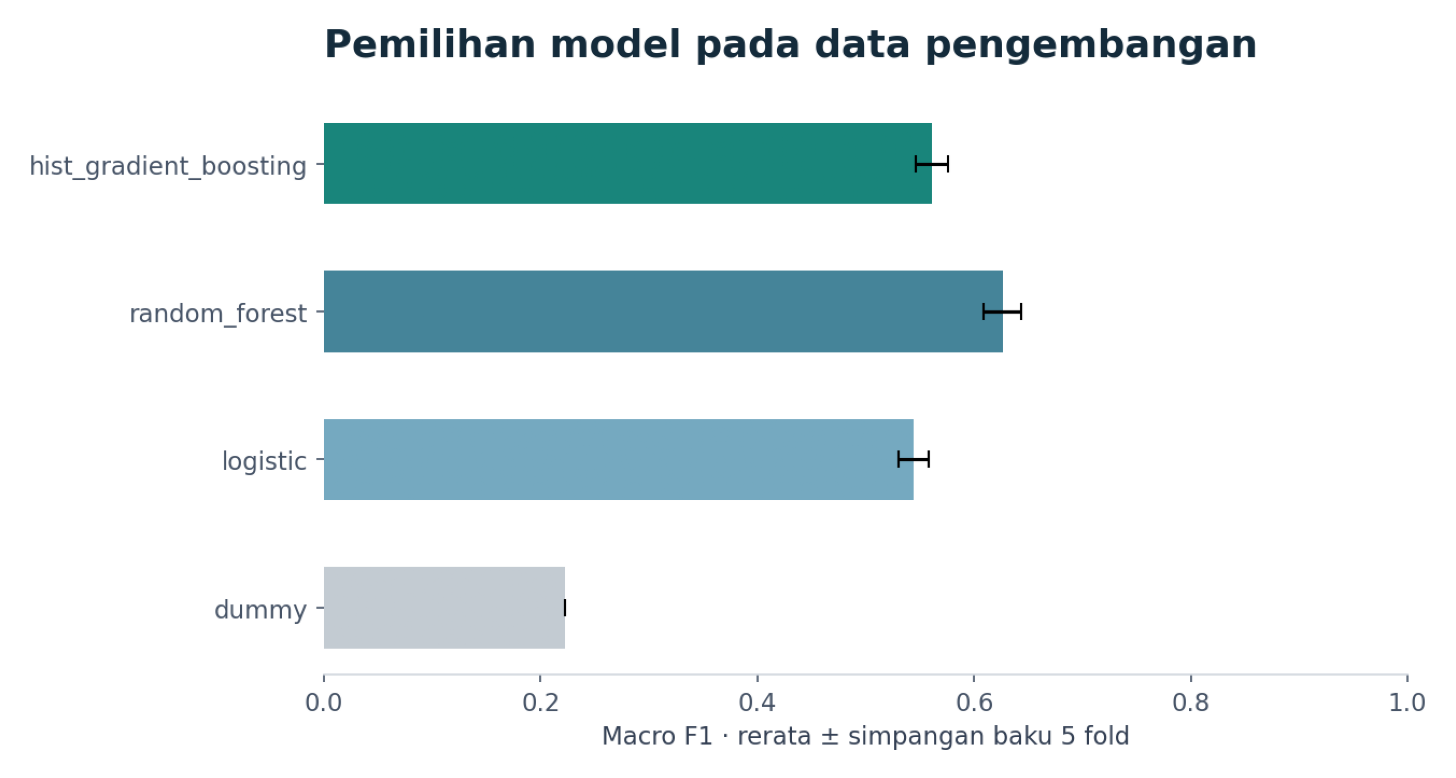

In [11]:
def show_plot(name):
    image = plt.imread(REPORT_DIR / 'figures' / f'{name}.png')
    height, width = image.shape[:2]
    fig, ax = plt.subplots(figsize=(11, 11 * height / width))
    ax.imshow(image)
    ax.axis('off')
    plt.tight_layout(pad=0)
    plt.show()
    plt.close(fig)

show_plot('model_selection')

In [12]:
print('Admission-only Logistic CV macro F1:', round(metrics['admission_logistic_cv_macro_f1'], 4))
print('Semester-1 Logistic CV macro F1:', round(float(comparison.loc[comparison.candidate == 'logistic', 'macro_f1_mean'].iloc[0]), 4))
print('Perbandingan ini memakai algoritma/prosedur yang sama dan subset fitur yang berbeda.')

Admission-only Logistic CV macro F1: 0.4266
Semester-1 Logistic CV macro F1: 0.5442
Perbandingan ini memakai algoritma/prosedur yang sama dan subset fitur yang berbeda.


### Pemilihan threshold

Kategori “Perlu peninjauan” memakai satu kondisi: probabilitas Dropout ≥ threshold terpilih. Kelas argmax tidak mengubah aturan ini. Saran akademik tambahan merupakan aturan pendampingan yang terpisah dari model.

Pemaksimalan F2 tidak membatasi jumlah kasus yang ditandai. Karena itu, review rate menjadi bagian hasil wajib; jika kapasitas institusi berbeda, threshold harus ditentukan ulang pada validasi sesuai kapasitas, lalu diuji dengan protokol baru.

In [13]:
thresholds = pd.read_csv(REPORT_DIR / 'threshold_analysis.csv')
thresholds.sort_values(['f2', 'threshold'], ascending=False).head(10)

,threshold,precision,recall,f2,review_rate,review_count,tp,fn,fp,tn
14,0.19,0.535948,0.866197,0.771160,0.518644,459,246,38,213,388
12,0.17,0.513347,0.880282,0.770179,0.550282,487,250,34,237,364
10,0.15,0.493204,0.894366,0.769231,0.581921,515,254,30,261,340
9,0.14,0.484848,0.901408,0.769231,0.596610,528,256,28,272,329
15,0.20,0.547297,0.855634,0.768987,0.501695,444,243,41,201,400
13,0.18,0.524416,0.869718,0.768513,0.532203,471,247,37,224,377
8,0.13,0.471664,0.908451,0.766488,0.618079,547,258,26,289,312
16,0.21,0.556845,0.845070,0.765795,0.487006,431,240,44,191,410
11,0.16,0.501002,0.880282,0.764526,0.563842,499,250,34,249,352
7,0.12,0.456294,0.919014,0.764052,0.646328,572,261,23,311,290


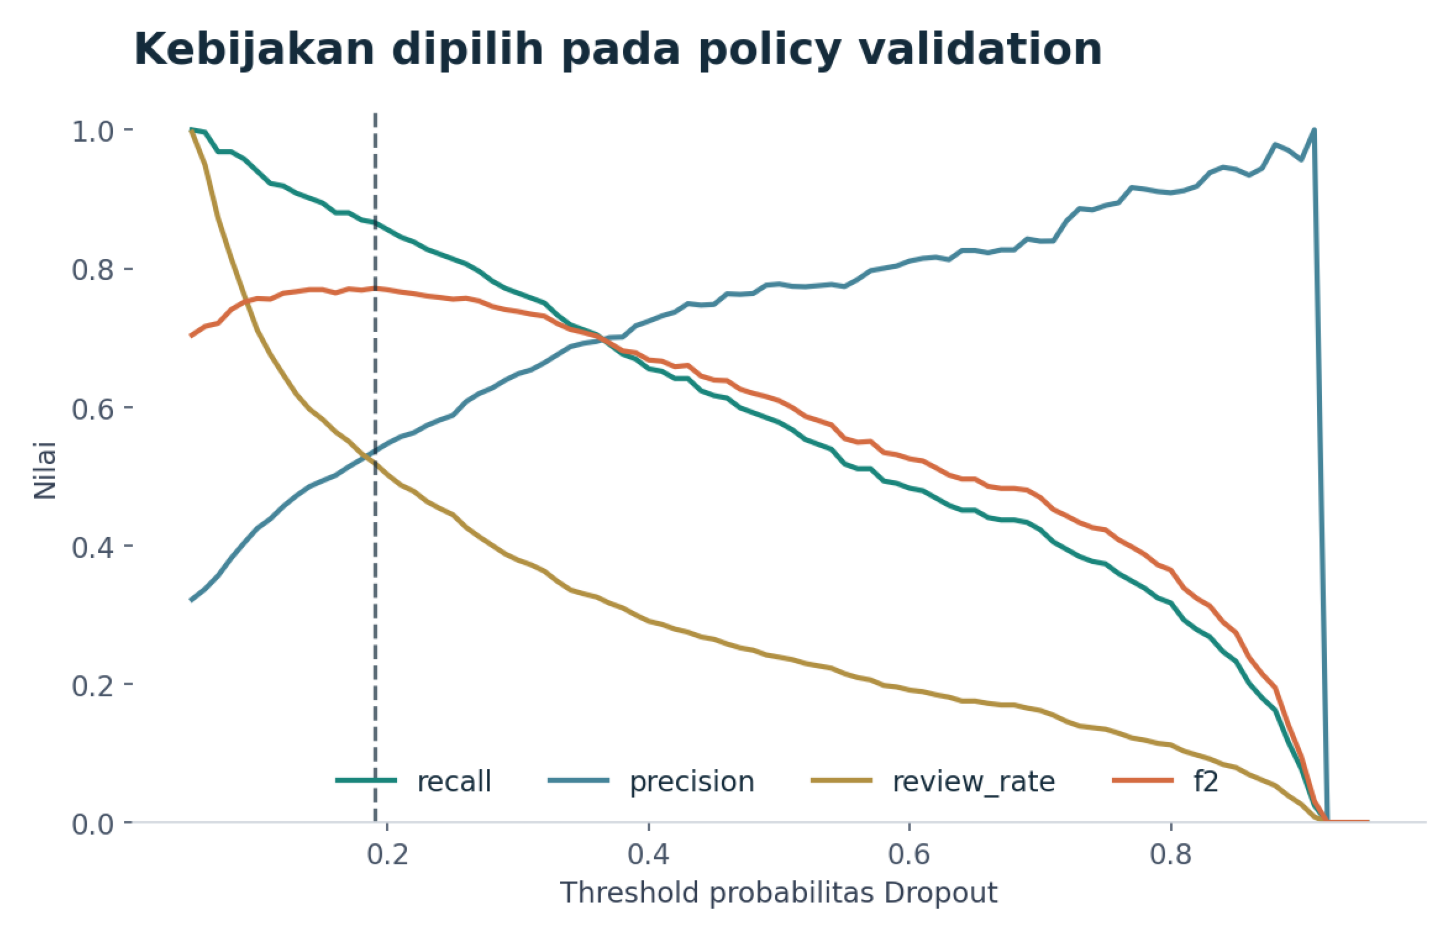

In [14]:
show_plot('threshold_selection')

## 5. Evaluasi pada holdout historis

Hasil di bawah dihitung setelah model dan threshold dikunci. Accuracy/macro F1 mengukur klasifikasi tiga kelas; precision/recall kebijakan mengukur peninjauan Dropout berdasarkan threshold. Keduanya tidak boleh disamakan.

In [15]:
holdout = metrics['historical_holdout']
summary = {k: holdout[k] for k in ['n', 'accuracy', 'macro_f1', 'weighted_f1', 'log_loss', 'dropout_brier', 'dropout_average_precision']}
pd.DataFrame.from_dict(summary, orient='index', columns=['value'])

,value
n,885.000000
accuracy,0.708475
macro_f1,0.612870
weighted_f1,0.690411
log_loss,0.706890
dropout_brier,0.133837
dropout_average_precision,0.778783


In [16]:
pd.DataFrame(holdout['classification_report']).T

,precision,recall,f1-score,support
Dropout,0.715385,0.654930,0.683824,284.000000
Enrolled,0.425743,0.270440,0.330769,159.000000
Graduate,0.759542,0.900452,0.824017,442.000000
accuracy,0.708475,0.708475,0.708475,0.708475
macro avg,0.633556,0.608607,0.612870,885.000000
weighted avg,0.685401,0.708475,0.690411,885.000000


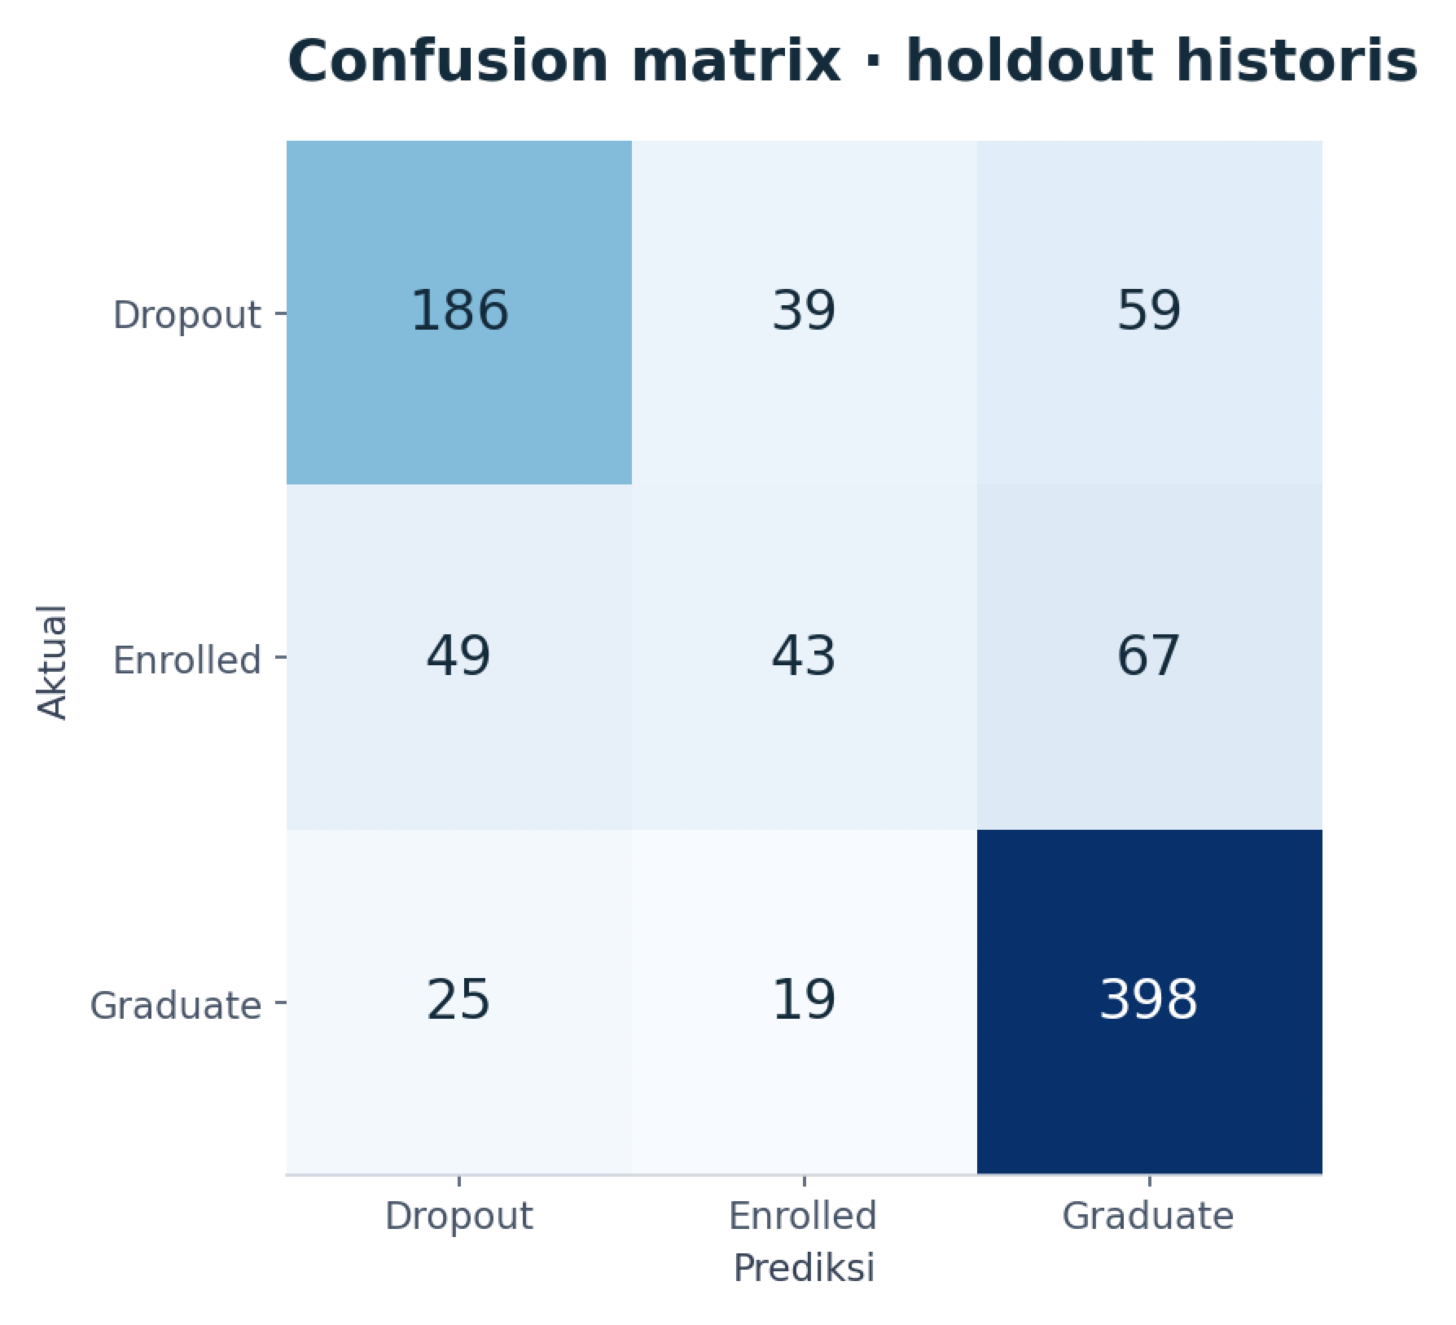

In [17]:
show_plot('confusion_matrix')

In [18]:
policy = holdout['policy']
print(f"Terdeteksi: {policy['tp']} dari {policy['tp'] + policy['fn']} Dropout")
print(f"Terlewat: {policy['fn']} | False positive: {policy['fp']}")
print(f"Perlu peninjauan: {policy['review_count']} dari {holdout['n']} ({policy['review_rate']:.1%})")
pd.DataFrame.from_dict(policy, orient='index', columns=['value'])

Terdeteksi: 250 dari 284 Dropout
Terlewat: 34 | False positive: 206
Perlu peninjauan: 456 dari 885 (51.5%)


,value
threshold,0.190000
precision,0.548246
recall,0.880282
f2,0.785176
review_rate,0.515254
review_count,456.000000
tp,250.000000
fn,34.000000
fp,206.000000
tn,395.000000


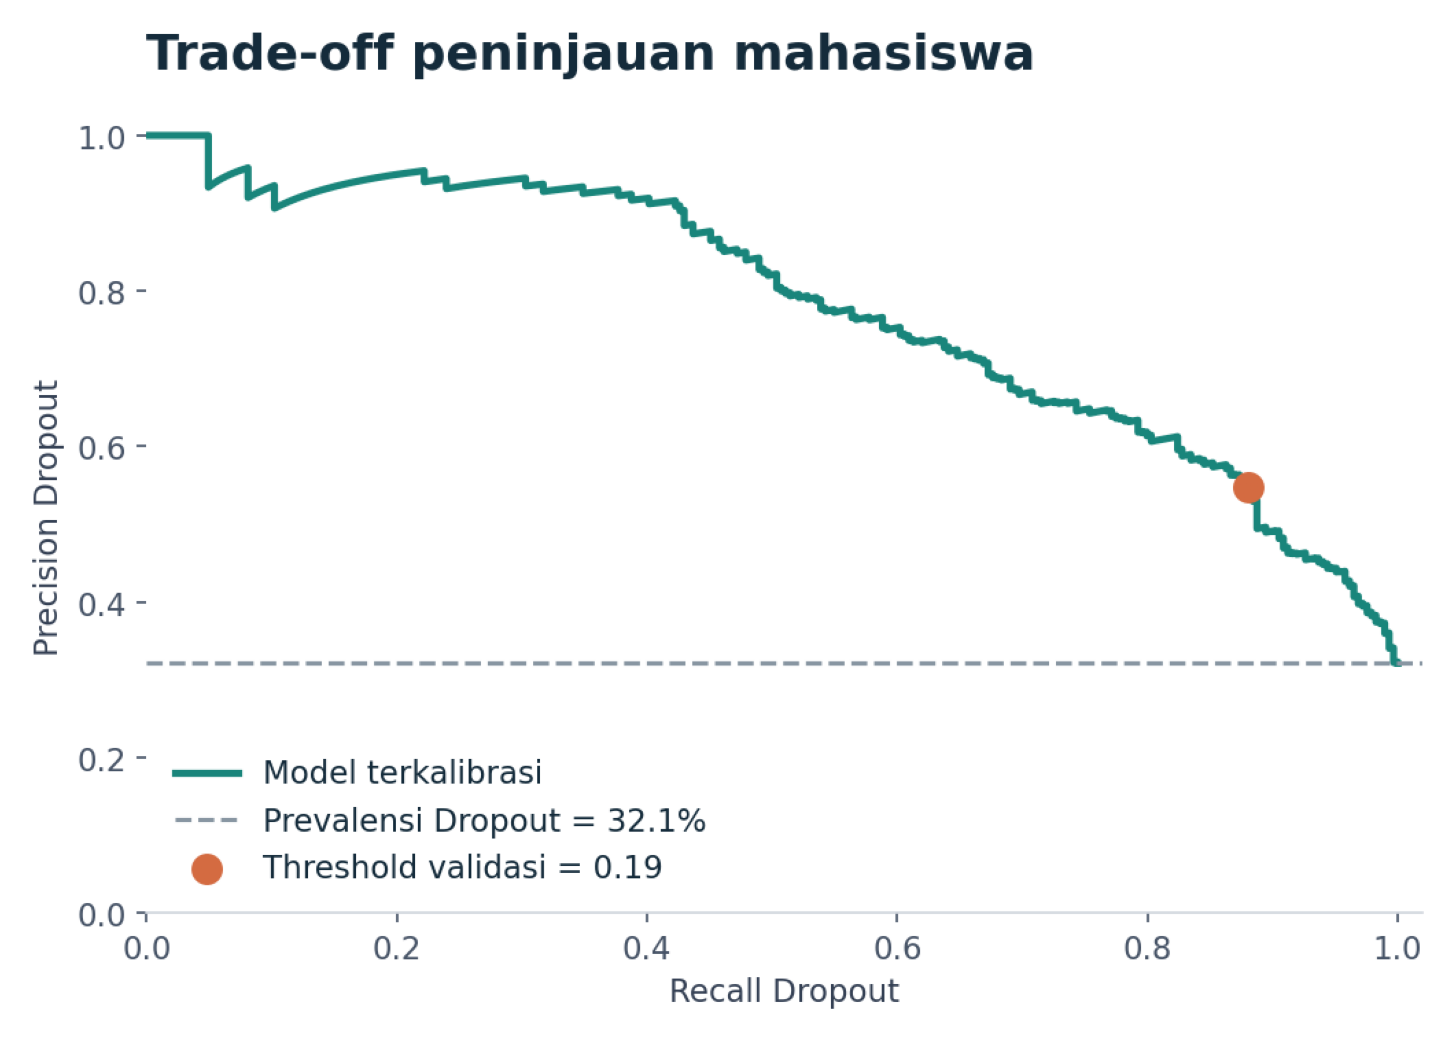

In [19]:
show_plot('precision_recall')

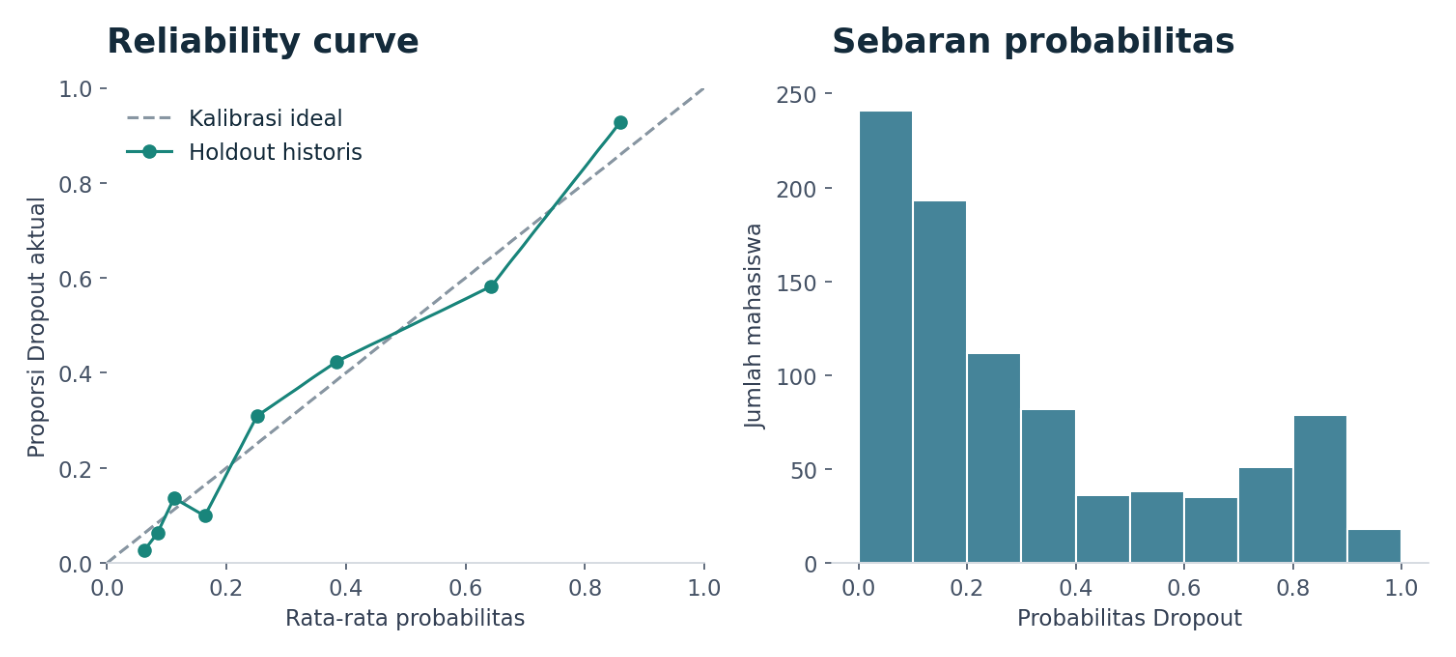

In [20]:
show_plot('calibration')

Kalibrasi tidak membuat probabilitas menjadi pasti. Reliability curve serta Brier score memberi bukti kesesuaian probabilitas dengan frekuensi pada data evaluasi. Dataset eksternal masih diperlukan.

Interval berikut menggunakan bootstrap baris untuk **model tetap**, 500 resampling. Interval tidak mencakup ketidakpastian training, pemilihan model, threshold, atau pergeseran institusi.

In [21]:
pd.DataFrame(metrics['bootstrap_95ci']).T

,lower,upper
macro_f1,0.578473,0.646881
dropout_recall_policy,0.842195,0.913768
dropout_precision_policy,0.501677,0.601169


## 6. Interpretasi, error kelompok, dan pola data

Permutation importance mengukur perubahan macro F1 saat satu fitur diacak. Nilai ini bukan efek kausal dan bukan penjelasan individual; korelasi antarfitur dapat membagi kontribusi. Diagnostik dilakukan setelah model dibekukan dan tidak digunakan untuk mengubah model dalam versi ini.

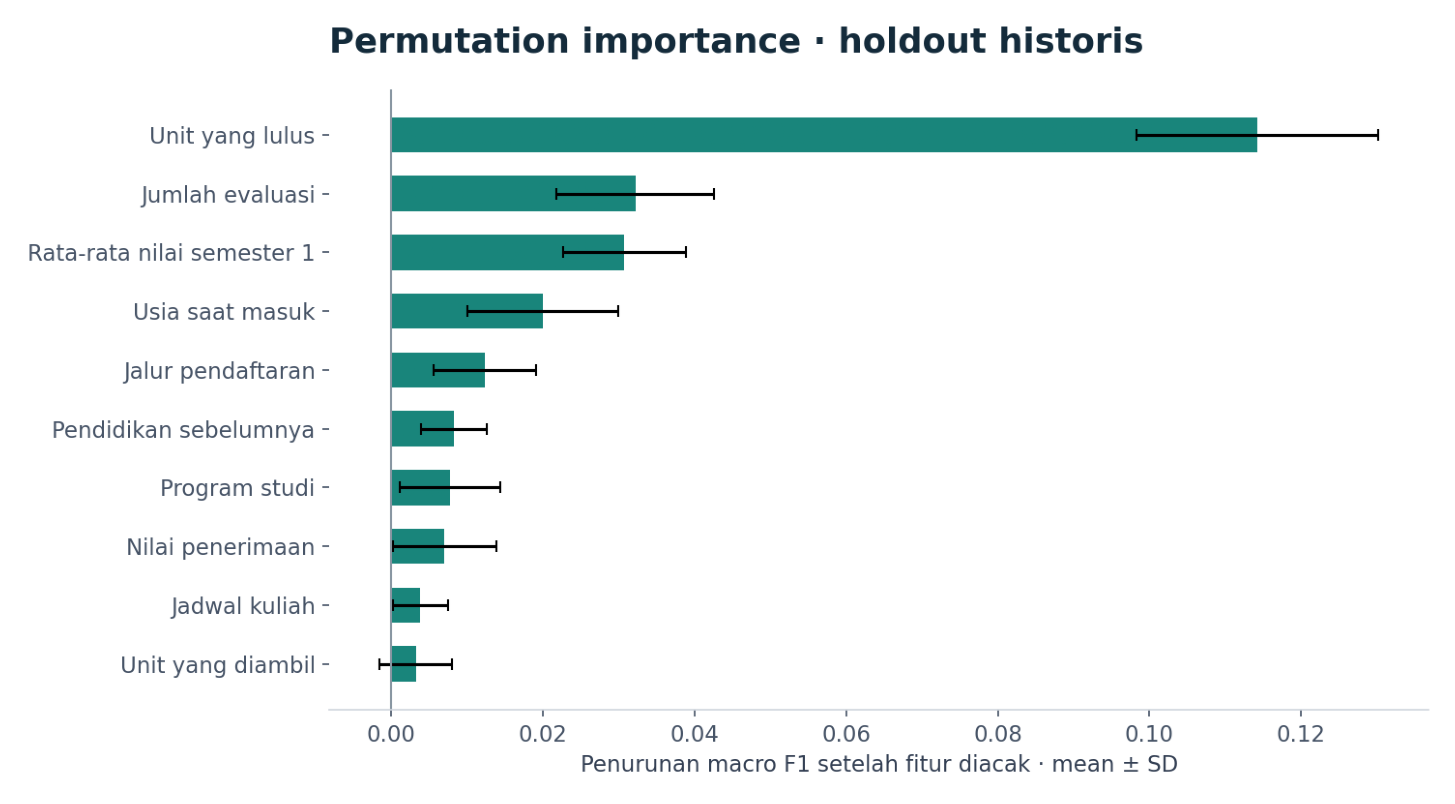

In [22]:
show_plot('feature_importance')

In [23]:
groups = pd.read_csv(REPORT_DIR / 'subgroup_metrics.csv')
groups[['attribute','group','n','actual_dropout','precision','recall','review_rate','fn']]

,attribute,group,n,actual_dropout,precision,recall,review_rate,fn
0,Gender,0,570,139,0.462151,0.834532,0.440351,23
1,Gender,1,315,145,0.653659,0.924138,0.650794,11
2,Age_group,16–24,651,155,0.488189,0.800000,0.390169,31
3,Age_group,25+,234,129,0.623762,0.976744,0.863248,3
4,Scholarship_holder,0,680,265,0.580097,0.901887,0.605882,26
5,Scholarship_holder,1,205,19,0.250000,0.578947,0.214634,8


Perbedaan error antar kelompok perlu diperhatikan sebelum penggunaan nyata. Gender dan scholarship tidak masuk model, tetapi perbedaan masih dapat muncul melalui distribusi fitur lain. Pada kelompok dengan sedikit kejadian Dropout, estimasi recall lebih tidak stabil. Tabel ini belum merupakan sertifikasi fairness.

Grafik berikut menggambarkan seluruh dataset historis. Grafik digunakan sebagai konteks deskriptif, bukan sebagai bukti kausal atau dasar memilih parameter model setelah evaluasi.

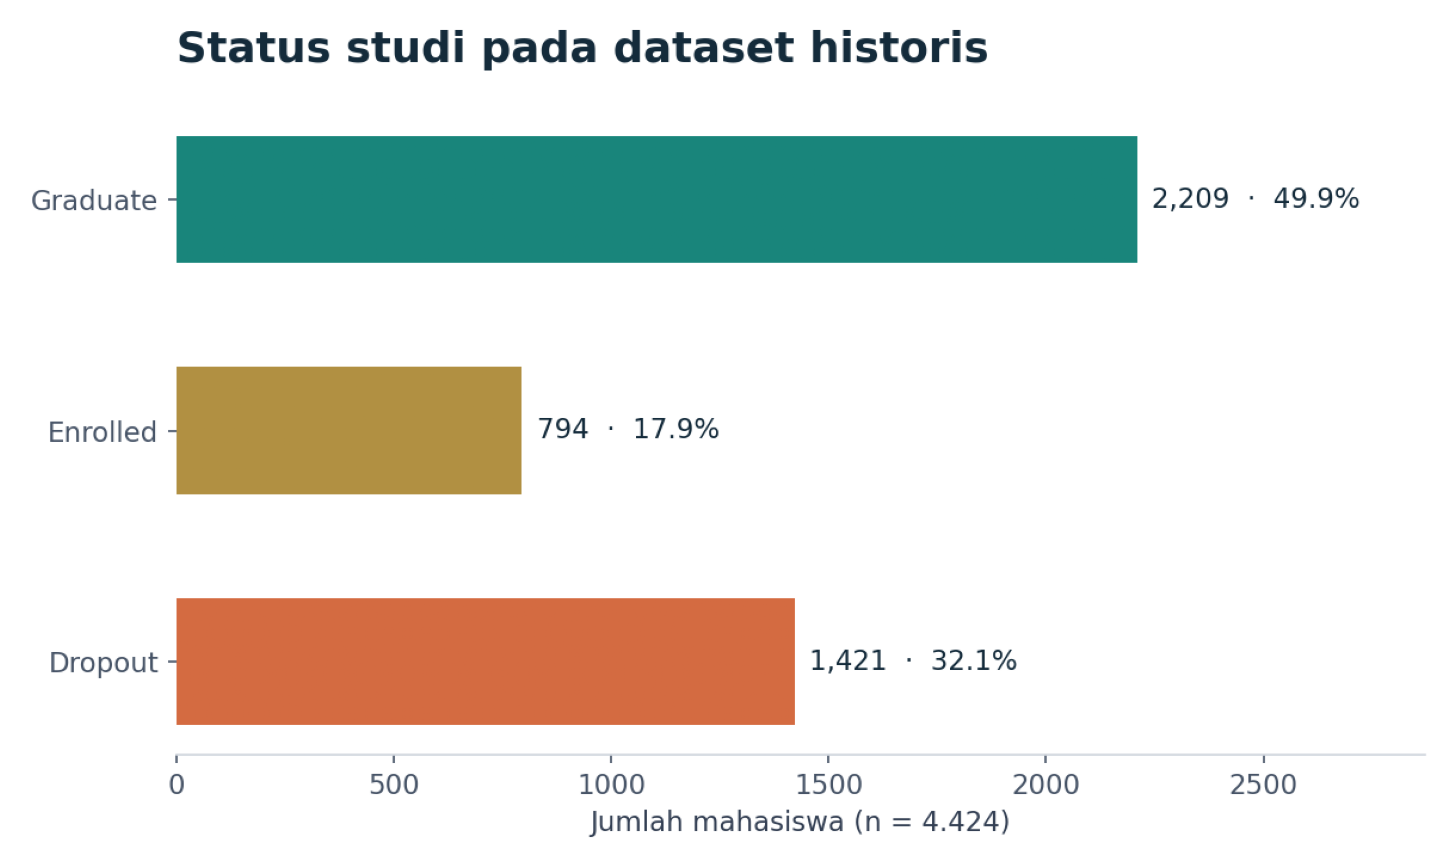

In [24]:
show_plot('status_distribution')

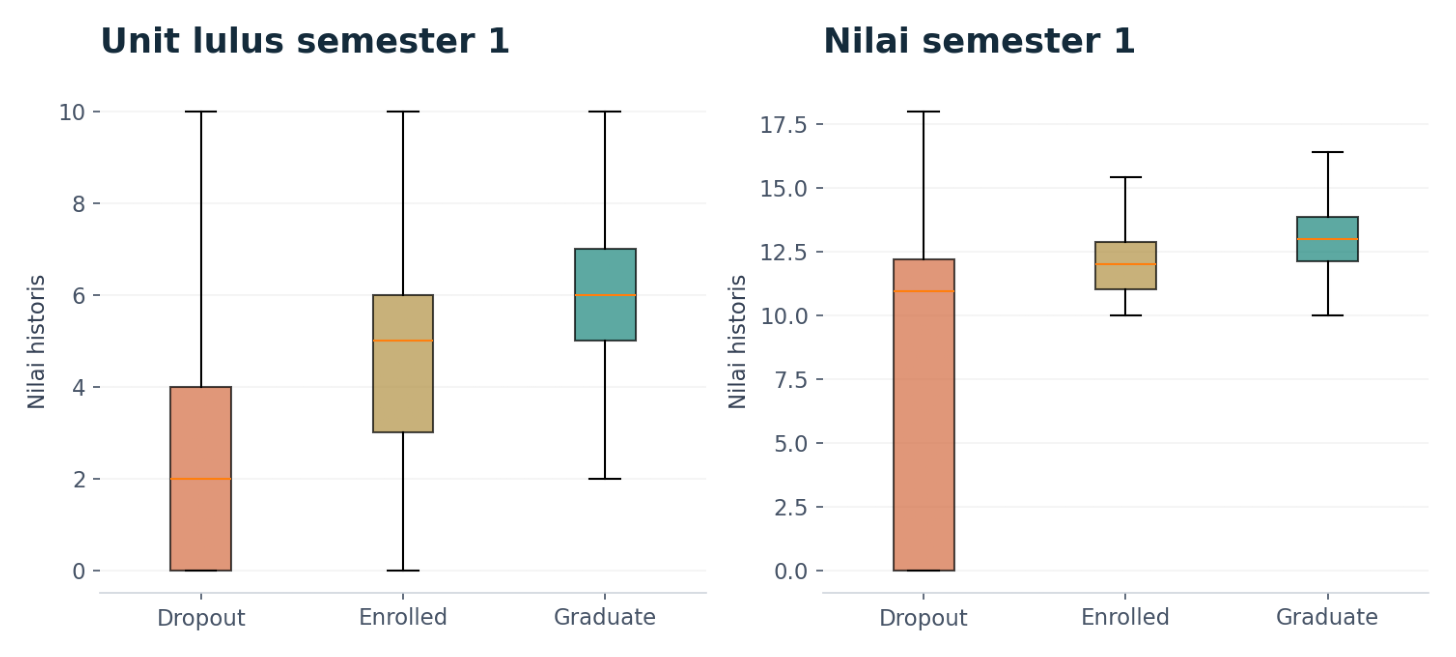

In [25]:
show_plot('academic_patterns')

In [26]:
correlations = {
    sem: data[f'Curricular_units_{sem}_sem_enrolled'].corr(data[f'Curricular_units_{sem}_sem_approved'])
    for sem in ['1st','2nd']
}
print('Korelasi enrolled–approved (audit ulang):', correlations)
print('Semester 2 ditampilkan hanya untuk koreksi dokumentasi historis, tidak masuk model utama.')

Korelasi enrolled–approved (audit ulang): {'1st': np.float64(0.7690834766824147), '2nd': np.float64(0.7032580730157251)}
Semester 2 ditampilkan hanya untuk koreksi dokumentasi historis, tidak masuk model utama.


## 7. Deployment dan kesetaraan training–inference

Satu model terkalibrasi dan manifest dipakai oleh prediksi individu maupun batch. Aplikasi memverifikasi checksum, versi scikit-learn, urutan fitur, serta kelas. Pengguna hanya mengunggah CSV, tidak mengunggah pickle.

Artefak disimpan langsung ke `artifacts/`; tidak ada langkah memindahkan model dari root secara manual.
Dashboard historis berada dalam aplikasi Streamlit yang sama sehingga tidak memerlukan database Metabase untuk versi portofolio.

In [27]:
model, bundle = load_bundle()
examples = pd.read_csv(ROOT / 'examples' / 'students_template.csv')
results = predict_frame(examples, model, bundle)
results[['source_row','predicted_status','prob_dropout','prob_enrolled','prob_graduate','action']]

,source_row,predicted_status,prob_dropout,prob_enrolled,prob_graduate,action
0,1,Enrolled,0.202956,0.438287,0.358757,Perlu peninjauan
1,2,Dropout,0.636281,0.271000,0.092719,Perlu peninjauan
2,3,Graduate,0.081307,0.204671,0.714023,Pemantauan rutin


In [28]:
single = predict_frame(examples.iloc[[0]], model, bundle)
np.testing.assert_allclose(single[['prob_dropout','prob_enrolled','prob_graduate']].to_numpy(), results[['prob_dropout','prob_enrolled','prob_graduate']].iloc[[0]].to_numpy())
print('PASS: prediksi individu sama dengan baris yang sesuai pada batch.')
print('Model checksum:', bundle['model_sha256'])
pd.DataFrame.from_dict(bundle['environment'], orient='index', columns=['version'])

PASS: prediksi individu sama dengan baris yang sesuai pada batch.
Model checksum: d5a6fb0417668b16d313bc58b3e35d7e263e25d7b92b6dd7ae1e6c5ba79aa6f1


,version
scikit-learn,1.8.0
numpy,2.3.5
pandas,2.2.3
scipy,1.17.0
joblib,1.5.3
matplotlib,3.10.8
python,3.12.14


## 8. Kesimpulan dan rekomendasi tindakan

Proyek menyediakan baseline semester-1 dengan seleksi model, kalibrasi, threshold validation, dan inference yang konsisten. Hasil menunjukkan trade-off nyata antara mahasiswa Dropout yang terdeteksi dan jumlah profil yang perlu ditinjau.

**Interpretasi hasil:** model semester-1 tidak boleh diklaim mengungguli atau kalah secara setara terhadap model lama yang memakai informasi semester-2/finansial. Tujuan, fitur, dan proses evaluasi berbeda.

| Usulan tindakan | Penanggung jawab calon | Ukuran evaluasi yang perlu dikumpulkan |
|---|---|---|
| Meninjau profil yang ditandai | Dosen wali | Waktu peninjauan, proporsi kasus yang dikonfirmasi memerlukan bantuan |
| Mengklarifikasi unit tanpa evaluasi | Dosen wali dan administrasi | Kelengkapan catatan, alasan ketidakhadiran |
| Menawarkan pendampingan akademik | Tim akademik | Partisipasi, capaian pada evaluasi berikutnya |
| Menguji pilot pada cohort baru | Tim data dan institusi | Recall, precision, workload, kalibrasi, error kelompok |

Semua tindakan merupakan rancangan pilot, bukan hasil intervensi yang sudah terbukti. Manfaat aktual harus diukur setelah memperoleh data dan persetujuan institusi terkait.

**Menjalankan aplikasi:** `streamlit run app.py` setelah instalasi `requirements.txt`.
**Pengujian:** `python -m unittest discover -s tests -v`.
**Dokumentasi:** README, `docs/BUSINESS_CASE.md`, `docs/MODEL_CARD.md`, `docs/DATA_CARD.md`, dan `docs/MIGRATION.md`.

Referensi: [UCI](https://doi.org/10.24432/C5MC89), [Dicoding dataset](https://github.com/dicodingacademy/dicoding_dataset/tree/main/students_performance), [scikit-learn cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html), [calibration](https://scikit-learn.org/stable/modules/calibration.html).